In [12]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Gözlemlenen Trafik Verisi (1 dakikada geçen araç sayısı) [cite: 22]
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

print(f"Veri Seti: {traffic_data}")
print(f"Gözlem Sayısı (n): {len(traffic_data)}")
print(f"Aritmetik Ortalama: {np.mean(traffic_data):.4f}")

Veri Seti: [12 15 10  8 14 11 13 16  9 12 11 14 10 15]
Gözlem Sayısı (n): 14
Aritmetik Ortalama: 12.1429


## Bölüm 1: Teorik Türetme

### 1.1. Likelihood (Olabilirlik) Fonksiyonu [cite: 7-9]
Poisson dağılımı için Likelihood fonksiyonu $L(\lambda)$:
$$L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \cdot \lambda^{k_i}}{k_i!}$$

### 1.2. Log-Likelihood Fonksiyonu [cite: 10]
Doğal logaritma alarak türetilen $l(\lambda)$:
$$l(\lambda) = \sum_{i=1}^{n} [-\lambda + k_i \ln(\lambda) - \ln(k_i!)]$$
$$l(\lambda) = -n\lambda + \ln(\lambda) \sum_{i=1}^{n} k_i - \sum_{i=1}^{n} \ln(k_i!)$$

### 1.3. MLE Parametresinin Türetilmesi 
$\lambda$'ya göre türev alıp sıfıra eşitlediğimizde:
$$\frac{dl}{d\lambda} = -n + \frac{1}{\lambda} \sum_{i=1}^{n} k_i = 0$$
$$\hat{\lambda}_{MLE} = \frac{1}{n} \sum_{i=1}^{n} k_i$$
Bu sonuç, MLE tahmininin verilerin aritmetik ortalamasına eşit olduğunu kanıtlar.

In [15]:
def negative_log_likelihood(lam, data):
    """
    Poisson dağılımı için Negatif Log-Likelihood hesaplar. 
    log(k!) terimi sabit olduğu için ihmal edilmiştir. 
    """
    n = len(data)
    # nll = - (toplam log-likelihood) [cite: 27-29]
    nll = -(-n * lam + np.log(lam) * np.sum(data))
    return nll

# Başlangıç tahmini 
initial_guess = 1.0

# Scipy ile minimizasyon 
result = opt.minimize(negative_log_likelihood, initial_guess, 
                      args=(traffic_data,), bounds=[(0.001, None)])

mle_lambda = result.x[0]
print(f"Sayısal Tahmin (MLE lambda): {mle_lambda:.4f}")
print(f"Analitik Tahmin (Ortalama): {np.mean(traffic_data):.4f}")

Sayısal Tahmin (MLE lambda): 12.1429
Analitik Tahmin (Ortalama): 12.1429


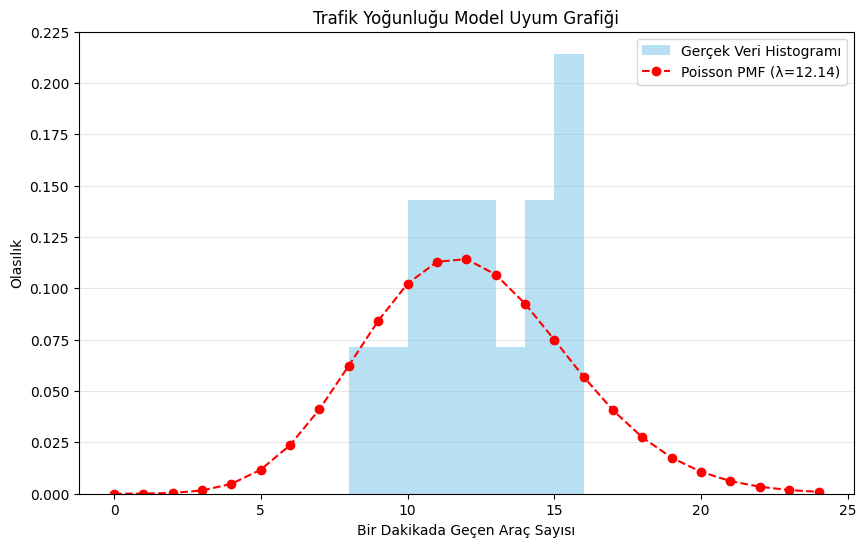

In [16]:
# PMF için x ekseni aralığı
x = np.arange(0, 25)
pmf = poisson.pmf(x, mle_lambda)

plt.figure(figsize=(10, 6))

# Gerçek veri histogramı [cite: 41]
plt.hist(traffic_data, bins=8, density=True, alpha=0.6, color='skyblue', label='Gerçek Veri Histogramı')

# Poisson PMF grafiği [cite: 40]
plt.plot(x, pmf, 'ro--', label=f'Poisson PMF (λ={mle_lambda:.2f})')

plt.title('Trafik Yoğunluğu Model Uyum Grafiği')
plt.xlabel('Bir Dakikada Geçen Araç Sayısı')
plt.ylabel('Olasılık')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## Bölüm 4: Analiz ve Yorumlar

### 4.1. Outlier (Aykırı Değer) Etkisi [cite: 43-45]
Veri setine "200" araçlık bir hatalı gözlem eklenmesi durumunda:
* **Hassasiyet:** MLE yöntemi (ortalama tabanlı olduğu için) bu uç değerden aşırı derecede etkilenir. [cite_start]$\lambda$ değeri yapay olarak çok yükselecektir. [cite: 44]
* [cite_start]**Planlama Hatası:** Belediye bu hatalı veriye dayanarak yol kapasitesinin yetersiz olduğunu düşünebilir ve gereksiz yol genişletme gibi maliyetli yanlış kararlar alabilir. [cite: 45]
* [cite_start]**Sonuç:** MLE'nin bu hassasiyeti, veri setindeki gürültülerin temizlenmesi gerektiğini göstermektedir. [cite: 45]